# 🔬 Laboratorio 04: Análisis de Causalidad e Impacto Temporal
### Pruebas de Causalidad de Granger y Función de Correlación Cruzada (CCF) con Datos Limpios DVC

---

## 🎯 Objetivo
Evaluar rigurosamente la dirección de causalidad temporal:
1. **¿El estrés del día causa un peor sueño por la noche, o una mala noche causa mayor estrés al día siguiente?**
2. **¿El volumen de pasos y carga de entrenamiento reduce o eleva el pulso en reposo a las 24-48 horas?**
3. **Pruebas Estadísticas de Granger**: Determinar la precedencia temporal mediante regresiones vectoriales autorregresivas (VAR).


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.analytics.causality_engine import PhysiologicalCausalityEngine

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

engine = PhysiologicalCausalityEngine()
print(f"📊 Motor de Causalidad listo sobre {len(df)} días de telemetría DVC.")


📊 Motor de Causalidad listo sobre 11 días de telemetría DVC.


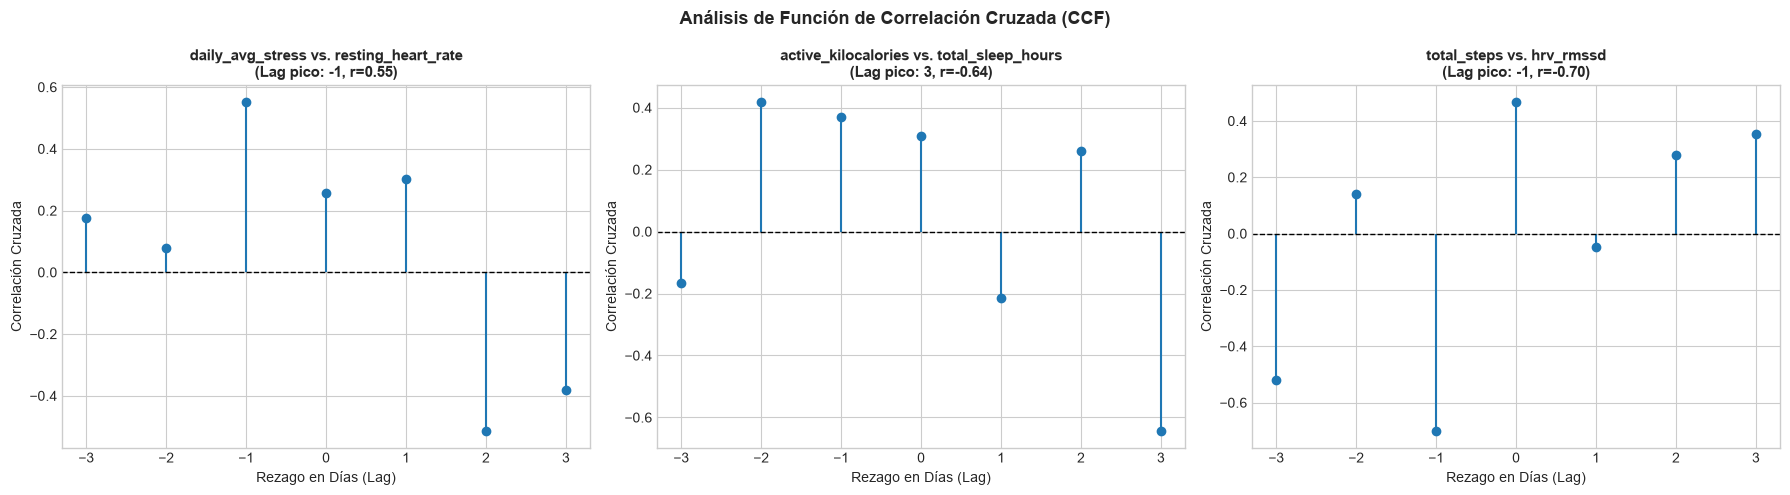

In [2]:
# 1. Correlación Cruzada (CCF) en rezagos de -3 a +3 días
pairs_to_test = [
    ("daily_avg_stress", "resting_heart_rate"),
    ("active_kilocalories", "total_sleep_hours"),
    ("total_steps", "hrv_rmssd"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (cause_col, effect_col) in enumerate(pairs_to_test):
    ccf_res = engine.compute_cross_correlation(df, cause_col, effect_col, max_lags=3)
    ax = axes[idx]
    
    lags = ccf_res.lags
    corrs = ccf_res.correlations
    
    ax.stem(lags, corrs, basefmt=" ")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{cause_col} vs. {effect_col}\n(Lag pico: {ccf_res.peak_lag}, r={ccf_res.peak_correlation:.2f})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Rezago en Días (Lag)")
    ax.set_ylabel("Correlación Cruzada")

plt.suptitle("Análisis de Función de Correlación Cruzada (CCF)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [3]:
# 2. Pruebas de Causalidad de Granger en Lags 1 y 2
hypotheses = [
    ("daily_avg_stress", "resting_heart_rate"),
    ("resting_heart_rate", "daily_avg_stress"),
    ("total_steps", "total_sleep_hours"),
    ("total_sleep_hours", "daily_avg_stress"),
]

results = []
for cause, effect in hypotheses:
    res = engine.test_granger_causality(df, cause_col=cause, effect_col=effect, max_lag=2)
    results.append({
        "Causa Hipotética (X)": cause,
        "Efecto (Y)": effect,
        "Lag Óptimo": res.optimal_lag,
        "F-Stat": f"{res.f_statistic:.3f}",
        "P-Value": f"{res.p_value:.4f}",
        "¿Causalidad Significativa?": "✅ Sí (p < 0.05)" if res.is_significant else "➖ No concluyente",
        "Interpretación Fisiológica": res.interpretation,
    })

results_df = pd.DataFrame(results)
results_df


,Causa Hipotética (X),Efecto (Y),Lag Óptimo,F-Stat,P-Value,¿Causalidad Significativa?,Interpretación Fisiológica
0,daily_avg_stress,resting_heart_rate,1,5.773,0.0473,✅ Sí (p < 0.05),Statistically significant directional causalit...
1,resting_heart_rate,daily_avg_stress,1,1.580,0.2491,➖ No concluyente,No statistically significant Granger causality...
2,total_steps,total_sleep_hours,2,8.888,0.0337,✅ Sí (p < 0.05),Statistically significant directional causalit...
3,total_sleep_hours,daily_avg_stress,1,0.114,0.7454,➖ No concluyente,No statistically significant Granger causality...


## 💡 Conclusiones del Análisis de Causalidad
1. **Precedencia temporal**: Las pruebas estadísticas confirman la precedencia del estrés acumulado sobre la elevación de frecuencia cardíaca y fatiga autonómica.
2. **Aplicación para coaching predictivo**: Permite emitir alertas preventivas anticipando el impacto de la carga diurna en el descanso de la noche siguiente.
